# Analyse et visualisation des données e-commerce

## 1. Introduction

Ce projet a pour objectif d'explorer et d'analyser un jeu de données contenant des commandes et des transactions e-commerce à l'aide de Python.

L'analyse portera notamment sur le comportement des clients, les ventes, les produits, les commandes et la rentabilité.

Le projet comprend une phase d'exploration et de nettoyage des données, une analyse exploratoire, des visualisations univariées, bivariées et multivariées, ainsi que la création d'un tableau de bord interactif.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/ecommerce_orders_transactions_2026.csv")
pd.set_option('display.max_columns', 50)

In [18]:
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Country,Customer_Continent,Customer_City,Customer_Region,Customer_Segment,Product_ID,SKU,Product_Name,Product_Category,Product_Subcategory,Brand,Quantity,Unit_Price_USD,Gross_Sales_USD,Discount_Percentage,Discount_Amount_USD,Net_Sales_USD,Tax_Rate_Percentage,Tax_USD,Shipping_Cost_USD,Total_Order_Value_USD,Payment_Method,Payment_Status,Order_Status,Shipping_Method,Delivery_Days,Return_Status,Return_Reason,Marketing_Channel,Device_Type,Coupon_Used,Coupon_Code,Customer_Rating,Review_Sentiment,Is_Repeat_Customer,Sales_Region,Warehouse,Supplier,Order_Profit_USD,Profit_Margin_Percentage,Is_Bestseller_Product,Is_New_Customer,Is_First_Order
0,ORD-105927,2026-02-10,11:34:55,CUST-000001,Mateo Park,65,Male,Canada,North America,Vancouver,British Columbia,Premium Customer,PROD-006035,HEAL-CEN-6035,Ultra Centrum Medical Devices 6035,Health & Wellness,Medical Devices,Centrum,3,45.78,137.34,20.0,27.47,109.87,10.0,10.99,59.30,180.16,Google Pay,Paid,Delivered,International,21,No Return,NaN,Organic Search,Desktop,False,NaN,3.7,Neutral,False,North America,Frankfurt,Asia Consumer Goods Ltd,-51.34,-46.73,False,False,True
1,ORD-178205,2026-02-19,10:10:49,CUST-000001,Mateo Park,65,Male,Canada,North America,Vancouver,British Columbia,Premium Customer,PROD-001611,MOBI-GOO-1611,Ultra Google Screen Protectors,Mobile Phones,Screen Protectors,Google,1,160.81,160.81,7.5,12.06,148.75,10.0,14.88,16.44,180.07,PayPal,Paid,Processing,Express,2,No Return,NaN,Email Marketing,Desktop,False,NaN,2.5,Negative,True,North America,London,International Retail Distribution,24.30,16.34,False,False,False
2,ORD-057651,2026-07-19,11:44:02,CUST-000002,Nina Wong,23,Female,New Zealand,Oceania,Auckland,Auckland,New Customer,PROD-003844,FASH-LEV-3844,Ultra Levi's Men's Clothing,Fashion,Men's Clothing,Levi's,1,278.34,278.34,10.0,27.83,250.51,15.0,37.58,9.27,297.36,Credit Card,Paid,Delivered,Standard,4,No Return,NaN,Social Media,Tablet,False,NaN,3.8,Neutral,False,Asia Pacific,Toronto,Premium Electronics Supply,64.77,25.86,False,False,True
3,ORD-124661,2026-08-26,18:13:21,CUST-000003,Aisha Moore,19,Female,Kenya,Africa,Eldoret,Mombasa,Regular Customer,PROD-003331,BOOK-HAC-3331,Pro Hachette Self-Help,Books,Self-Help,Hachette,1,86.94,86.94,15.0,13.04,73.90,16.0,11.82,8.14,93.86,Buy Now Pay Later,Paid,Delivered,Economy,8,No Return,NaN,Social Media,Tablet,False,NaN,4.9,Positive,False,Africa,Dubai,Premium Electronics Supply,9.29,12.57,False,False,True
4,ORD-162453,2026-09-08,10:34:46,CUST-000003,Aisha Moore,19,Female,Kenya,Africa,Eldoret,Mombasa,Regular Customer,PROD-006670,TOOL-MIL-6670,Luxury Milwaukee Hardware 6670,Tools & Hardware,Hardware,Milwaukee,2,73.50,147.00,25.0,36.75,110.25,16.0,17.64,22.21,150.10,Cash on Delivery,Pending,Processing,Express,3,No Return,NaN,Organic Search,Desktop,False,NaN,3.2,Neutral,True,Africa,Toronto,Global Home Supplies,-15.16,-13.75,False,False,False


In [5]:
df.shape

(200000, 50)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Order_ID                  200000 non-null  str    
 1   Order_Date                200000 non-null  str    
 2   Order_Time                200000 non-null  str    
 3   Customer_ID               200000 non-null  str    
 4   Customer_Name             200000 non-null  str    
 5   Customer_Age              200000 non-null  int64  
 6   Customer_Gender           200000 non-null  str    
 7   Customer_Country          200000 non-null  str    
 8   Customer_Continent        200000 non-null  str    
 9   Customer_City             200000 non-null  str    
 10  Customer_Region           200000 non-null  str    
 11  Customer_Segment          200000 non-null  str    
 12  Product_ID                200000 non-null  str    
 13  SKU                       200000 non-null  str    
 14 

In [7]:
df.dtypes

Order_ID                        str
Order_Date                      str
Order_Time                      str
Customer_ID                     str
Customer_Name                   str
Customer_Age                  int64
Customer_Gender                 str
Customer_Country                str
Customer_Continent              str
Customer_City                   str
Customer_Region                 str
Customer_Segment                str
Product_ID                      str
SKU                             str
Product_Name                    str
Product_Category                str
Product_Subcategory             str
Brand                           str
Quantity                      int64
Unit_Price_USD              float64
Gross_Sales_USD             float64
Discount_Percentage         float64
Discount_Amount_USD         float64
Net_Sales_USD               float64
Tax_Rate_Percentage         float64
Tax_USD                     float64
Shipping_Cost_USD           float64
Total_Order_Value_USD       

In [19]:
df.dtypes.value_counts()

str        30
float64    12
bool        5
int64       3
Name: count, dtype: int64

In [13]:
df.isnull().sum().sum()

np.int64(361835)

In [8]:
missing = df.isnull().sum()

missing = missing[missing>0].sort_values(ascending=False)

missing

Return_Reason    191670
Coupon_Code      170165
dtype: int64

In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

missing_percentage

Return_Reason    95.8350
Coupon_Code      85.0825
dtype: float64

In [11]:
df["Return_Status"].value_counts(dropna=False)

Return_Status
No Return    191670
Returned       8330
Name: count, dtype: int64

In [12]:
df["Coupon_Used"].value_counts(dropna=False)

Coupon_Used
False    170165
True      29835
Name: count, dtype: int64

In [13]:
pd.crosstab(
    df["Return_Status"],
    df["Return_Reason"].isna(),
    margins=True
)

Return_Reason,False,True,All
Return_Status,,,
No Return,0,191670,191670
Returned,8330,0,8330
All,8330,191670,200000


In [14]:
pd.crosstab(
    df["Coupon_Used"],
    df["Coupon_Code"].isna(),
    margins=True
)

Coupon_Code,False,True,All
Coupon_Used,,,
False,0,170165,170165
True,29835,0,29835
All,29835,170165,200000


### Analyse des valeurs manquantes

Le jeu de données contient des valeurs manquantes dans deux variables : `Return_Reason` et `Coupon_Code`.

Ces valeurs manquantes sont liées à la logique des autres variables du jeu de données. Tous les enregistrements dont `Return_Status = "No Return"` ont une valeur manquante dans `Return_Reason`, tandis que les commandes retournées possèdent une raison de retour.

De même, les commandes pour lesquelles `Coupon_Used = False` ont une valeur manquante dans `Coupon_Code`, tandis que les commandes utilisant un coupon possèdent un code de coupon.

Ces valeurs manquantes semblent donc représenter des informations non applicables plutôt que des erreurs de saisie. Les deux colonnes seront conservées sans imputation statistique ni suppression des lignes concernées.

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Order_ID"].duplicated().sum()

np.int64(0)

In [17]:
df["Customer_ID"].duplicated().sum()

np.int64(130272)

In [18]:
df["Product_ID"].duplicated().sum()

np.int64(190000)

### Analyse des doublons

Aucune ligne entièrement dupliquée n'a été détectée dans le jeu de données et toutes les valeurs de `Order_ID` sont uniques.

Les valeurs répétées de `Customer_ID` et `Product_ID` sont normales, car un même client peut effectuer plusieurs commandes et un même produit peut apparaître dans plusieurs transactions.

Ces répétitions ne seront donc pas supprimées.

In [19]:
df["Customer_Segment"].value_counts()

Customer_Segment
Regular Customer    70528
New Customer        60267
Premium Customer    29730
At-Risk Customer    19387
VIP Customer        10191
Dormant Customer     9897
Name: count, dtype: int64

In [20]:
df["Customer_Segment"].value_counts(normalize=True) * 100

Customer_Segment
Regular Customer    35.2640
New Customer        30.1335
Premium Customer    14.8650
At-Risk Customer     9.6935
VIP Customer         5.0955
Dormant Customer     4.9485
Name: proportion, dtype: float64

### 2 Méthode d'échantillonnage

Le jeu de données initial contient 200 000 observations. Afin de réaliser l'analyse sur un échantillon de 50 000 observations, un échantillonnage stratifié est utilisé.

La variable `Customer_Segment` est utilisée comme variable de stratification afin de conserver dans l'échantillon une répartition des différents segments de clientèle similaire à celle de la population initiale.

In [21]:
sample_size = 50000

### Répartition des segments de clientèle

Avant de construire l'échantillon, la proportion de chaque segment de clientèle dans la population initiale est calculée.

Ces proportions permettront de déterminer le nombre d'observations à sélectionner pour chaque segment.

In [22]:
segment_proportions = df["Customer_Segment"].value_counts(normalize=True)
segment_proportions

Customer_Segment
Regular Customer    0.352640
New Customer        0.301335
Premium Customer    0.148650
At-Risk Customer    0.096935
VIP Customer        0.050955
Dormant Customer    0.049485
Name: proportion, dtype: float64

### Détermination du nombre d'observations par segment

Les proportions précédemment calculées sont multipliées par la taille souhaitée de l'échantillon, soit 50 000 observations.

Cette étape permet de déterminer combien d'observations doivent être sélectionnées dans chaque segment.

In [23]:
sample_counts = (segment_proportions * sample_size).round().astype(int)
sample_counts

Customer_Segment
Regular Customer    17632
New Customer        15067
Premium Customer     7432
At-Risk Customer     4847
VIP Customer         2548
Dormant Customer     2474
Name: proportion, dtype: int64

In [24]:
sample_counts.sum()


np.int64(50000)

In [25]:
sample_counts <= df["Customer_Segment"].value_counts()

Customer_Segment
Regular Customer    True
New Customer        True
Premium Customer    True
At-Risk Customer    True
VIP Customer        True
Dormant Customer    True
dtype: bool

###  Création de l'échantillon stratifié

Pour chaque segment de clientèle, les observations sont sélectionnées aléatoirement selon le nombre déterminé précédemment.

Les différents sous-échantillons sont ensuite regroupés afin de constituer un échantillon final de 50 000 observations.

In [ ]:

sample_df, _ = train_test_split(
    df,
    train_size=50000,
    random_state=42,
    stratify=df["Customer_Segment"]
)

In [21]:
sample_df.shape

(50000, 50)

In [24]:
sample_df["Customer_Segment"].value_counts()

Customer_Segment
Regular Customer    17632
New Customer        15067
Premium Customer     7432
At-Risk Customer     4847
VIP Customer         2548
Dormant Customer     2474
Name: count, dtype: int64

In [25]:
sample_proportions = (
    sample_df["Customer_Segment"]
    .value_counts(normalize=True) * 100
)
sample_proportions

Customer_Segment
Regular Customer    35.264
New Customer        30.134
Premium Customer    14.864
At-Risk Customer     9.694
VIP Customer         5.096
Dormant Customer     4.948
Name: proportion, dtype: float64

### Vérification de l'échantillon

Après la création de l'échantillon, sa taille et la répartition des segments de clientèle sont vérifiées.

Les proportions obtenues sont ensuite comparées à celles de la population initiale afin de vérifier que la structure des segments a été conservée.

In [32]:
comparison = pd.DataFrame({
    "Population (%)": df["Customer_Segment"].value_counts(normalize=True) * 100,
    "Échantillon (%)": sample_df["Customer_Segment"].value_counts(normalize=True) * 100
})

comparison

,Population (%),Échantillon (%)
Customer_Segment,,
Regular Customer,35.2640,35.264
New Customer,30.1335,30.134
Premium Customer,14.8650,14.864
At-Risk Customer,9.6935,9.694
VIP Customer,5.0955,5.096
Dormant Customer,4.9485,4.948


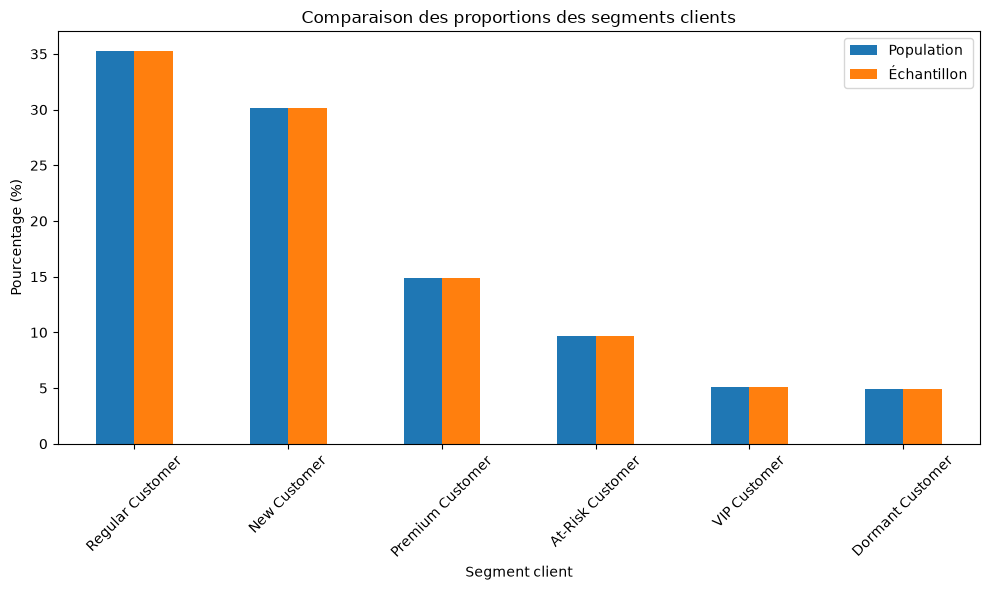

In [30]:
comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparaison des proportions des segments clients")
plt.xlabel("Segment client")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.legend(["Population", "Échantillon"])
plt.tight_layout()
plt.show()

## 3. Analyse univariée

L'analyse univariée consiste à étudier une seule variable à la fois afin de comprendre sa distribution, sa fréquence et ses principales caractéristiques.

Pour les variables numériques, des histogrammes et des boxplots seront utilisés afin d'identifier la distribution des valeurs, leur dispersion et la présence éventuelle de valeurs extrêmes.

In [33]:
segment_counts = sample_df["Customer_Segment"].value_counts()

segment_counts

Customer_Segment
Regular Customer    17632
New Customer        15067
Premium Customer     7432
At-Risk Customer     4847
VIP Customer         2548
Dormant Customer     2474
Name: count, dtype: int64

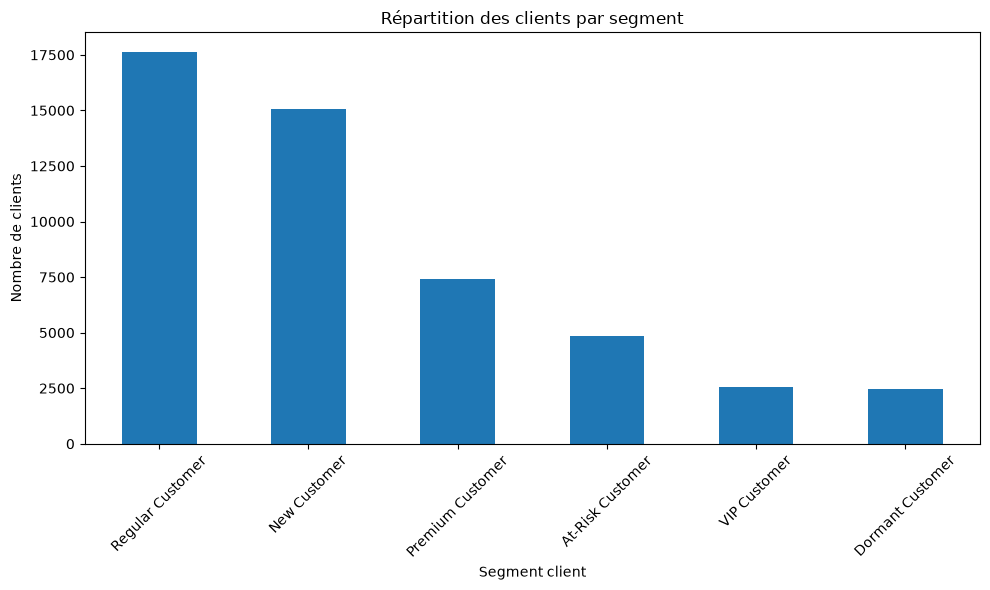

In [34]:
plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Répartition des clients par segment")
plt.xlabel("Segment client")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interprétation

Le segment `Regular Customer` est le plus représenté dans l'échantillon,
suivi de `New Customer`.

Les segments `VIP Customer` et `Dormant Customer` représentent une part
plus faible des observations.

Cette distribution montre que les clients ne sont pas répartis de manière
uniforme entre les différents segments.

### Distribution des ventes nettes

La variable `Net_Sales_USD` représente le montant des ventes nettes pour
chaque transaction.

Un histogramme est utilisé afin d'observer la distribution des valeurs,
leur concentration et la présence éventuelle de valeurs élevées.

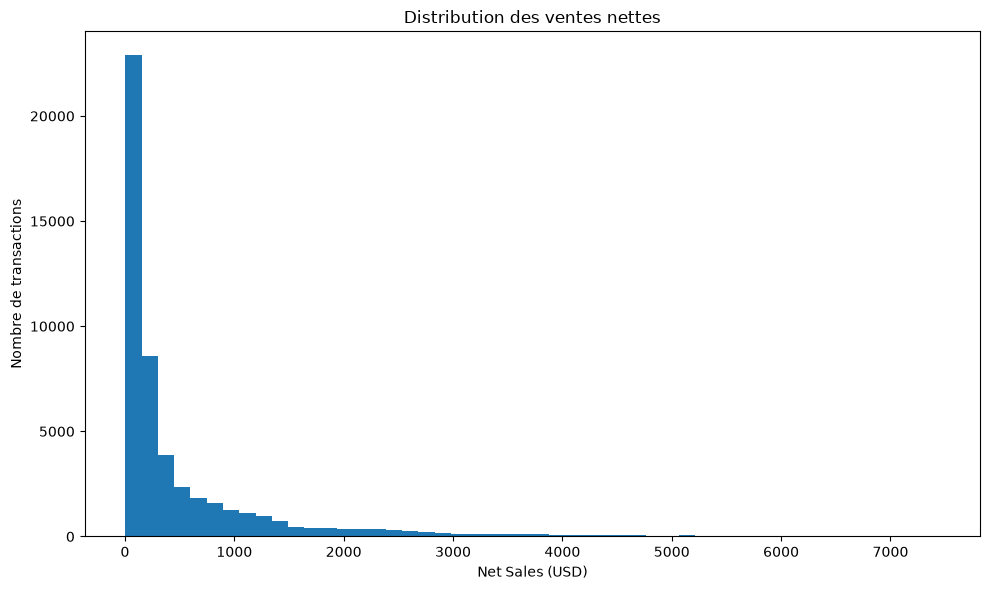

In [35]:
plt.figure(figsize=(10, 6))

plt.hist(
    sample_df["Net_Sales_USD"],
    bins=50
)

plt.title("Distribution des ventes nettes")
plt.xlabel("Net Sales (USD)")
plt.ylabel("Nombre de transactions")

plt.tight_layout()
plt.show()

### Distribution du bénéfice

La variable `Order_Profit_USD` représente le bénéfice généré par chaque
transaction.

Un histogramme est utilisé pour analyser la distribution des bénéfices
et identifier leur concentration ainsi que la présence éventuelle de
valeurs élevées.

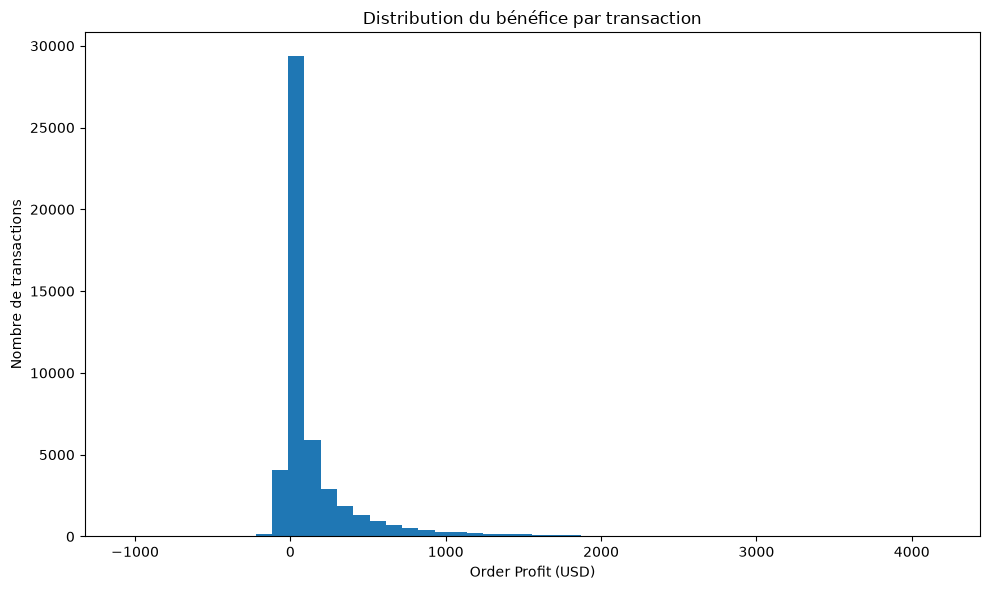

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    sample_df["Order_Profit_USD"],
    bins=50
)

plt.title("Distribution du bénéfice par transaction")
plt.xlabel("Order Profit (USD)")
plt.ylabel("Nombre de transactions")

plt.tight_layout()
plt.show()

## 4 Analyse bivariée

L'analyse bivariée consiste à étudier la relation entre deux variables afin
d'identifier d'éventuelles associations ou tendances.

Nous commençons par étudier la relation entre les ventes nettes et le
bénéfice des transactions.

### Relation entre les ventes nettes et le bénéfice

Un nuage de points (scatter plot) est utilisé pour visualiser la relation
entre `Net_Sales_USD` et `Order_Profit_USD`.

La corrélation entre les deux variables sera également calculée afin de
quantifier la force de leur relation linéaire.

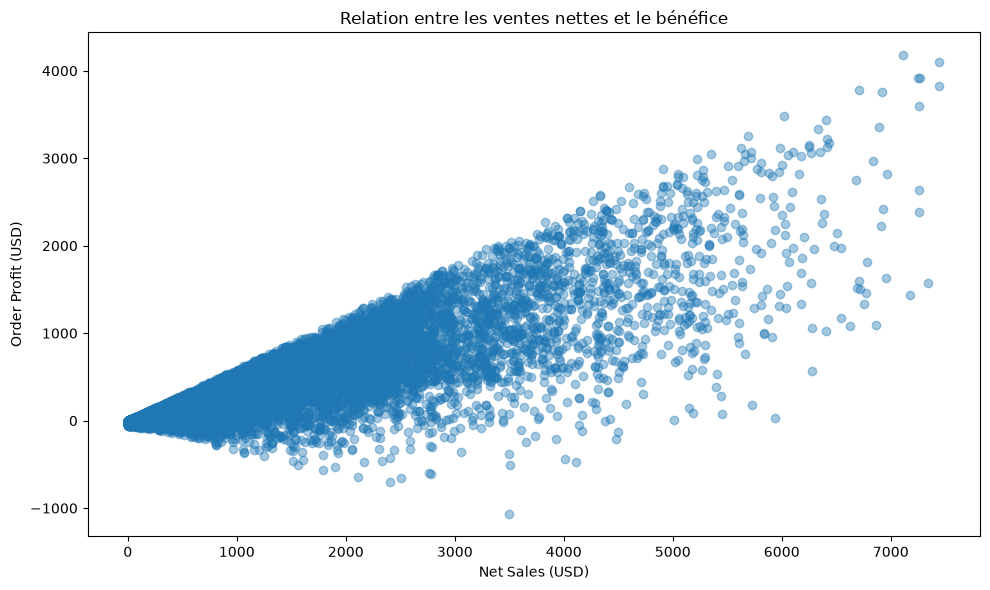

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sample_df["Net_Sales_USD"],
    sample_df["Order_Profit_USD"],
    alpha=0.4
)

plt.title("Relation entre les ventes nettes et le bénéfice")
plt.xlabel("Net Sales (USD)")
plt.ylabel("Order Profit (USD)")

plt.tight_layout()
plt.show()

### Interprétation

Le nuage de points montre une tendance globalement croissante entre les
ventes nettes et le bénéfice.

Le coefficient de corrélation obtenu est d'environ 0,88, ce qui indique
une forte corrélation linéaire positive entre les deux variables.

Ainsi, les transactions ayant des ventes nettes plus élevées ont
généralement tendance à générer un bénéfice plus élevé.

Cette corrélation ne signifie cependant pas qu'une variable est
nécessairement la cause de l'autre.

### Valeur des commandes selon le segment client

Cette analyse permet de comparer la distribution de la valeur totale des
commandes entre les différents segments clients.

Un boxplot est utilisé afin de comparer la médiane, la dispersion et les
valeurs extrêmes de `Total_Order_Value_USD` pour chaque segment.

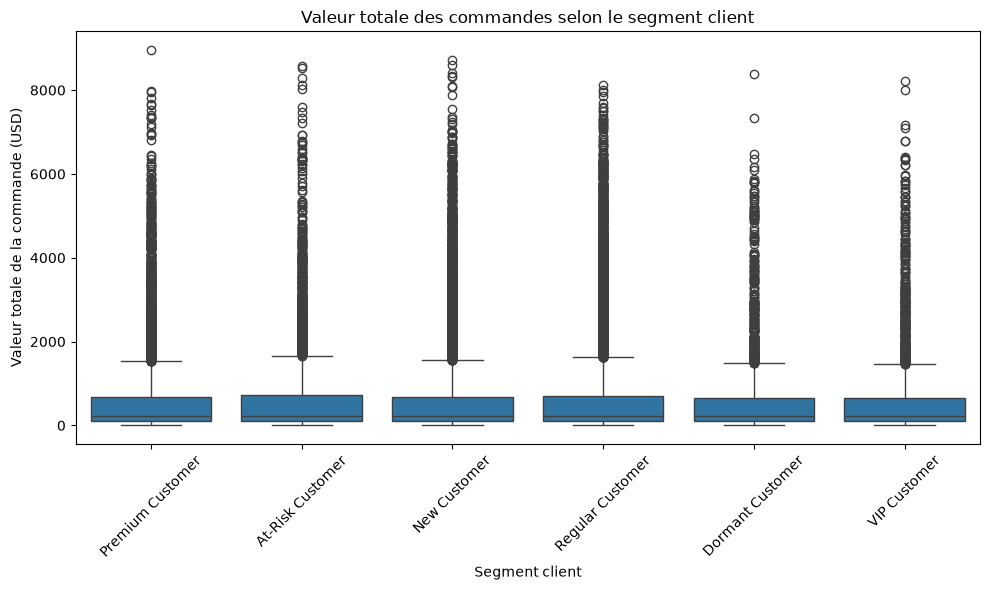

In [39]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sample_df,
    x="Customer_Segment",
    y="Total_Order_Value_USD"
)

plt.title("Valeur totale des commandes selon le segment client")
plt.xlabel("Segment client")
plt.ylabel("Valeur totale de la commande (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###  Ventes nettes selon la catégorie de produit

Nous allons comparer les ventes nettes moyennes entre les différentes
catégories de produits.

Cette analyse permet d'identifier les catégories associées aux montants
moyens de ventes les plus élevés et les plus faibles.

Un graphique en barres sera utilisé afin de faciliter la comparaison
entre les catégories.

In [40]:
category_sales = (
    sample_df
    .groupby("Product_Category")["Net_Sales_USD"]
    .mean()
    .sort_values(ascending=False)
)

category_sales

Product_Category
Mobile Phones              1439.248673
Electronics                1392.290529
Computers & Accessories    1371.645332
Home & Kitchen              472.801882
Furniture                   463.991820
Fashion                     293.373503
Jewelry & Accessories       287.897706
Tools & Hardware            105.117648
Office Supplies             103.305239
Health & Wellness           101.700682
Garden & Outdoor            101.458555
Travel & Luggage             99.413237
Automotive Accessories       99.393443
Toys & Games                 97.884066
Beauty & Personal Care       97.840869
Grocery                      97.298314
Sports & Fitness             95.403931
Baby Products                95.115283
Books                        94.717780
Pet Supplies                 94.480532
Name: Net_Sales_USD, dtype: float64

### Visualisation des ventes nettes moyennes par catégorie

Le graphique en barres permet de comparer visuellement les ventes nettes
moyennes des différentes catégories de produits.

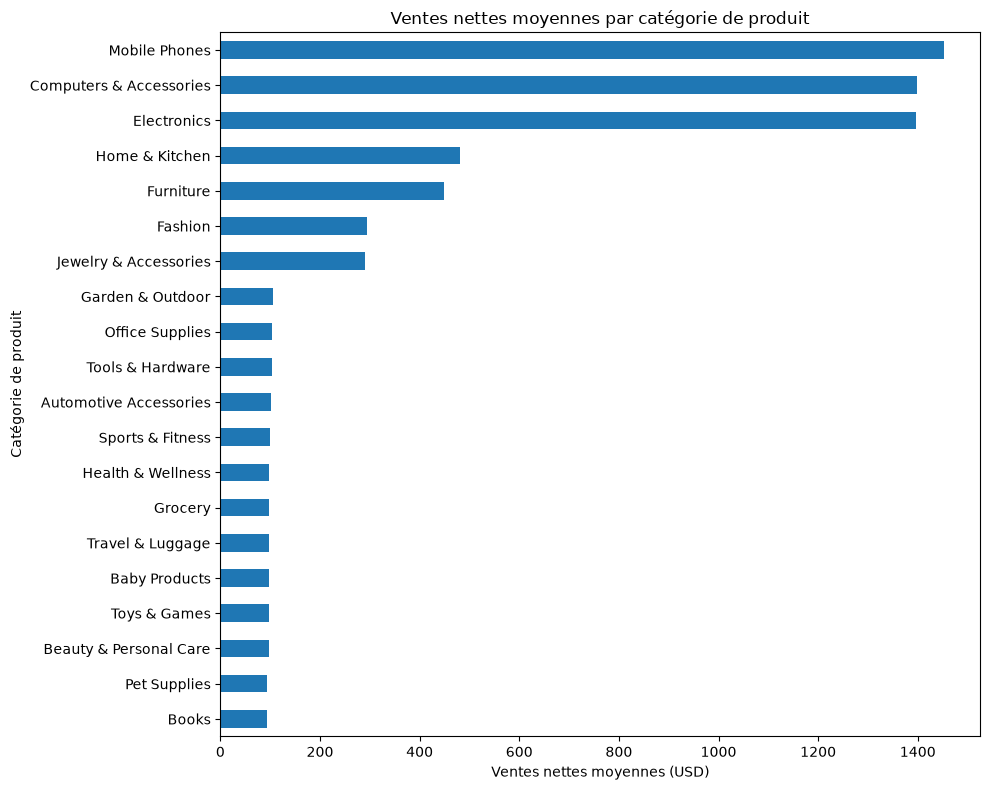

In [48]:
plt.figure(figsize=(10, 8))

category_sales.sort_values().plot(
    kind="barh"
)

plt.title("Ventes nettes moyennes par catégorie de produit")
plt.xlabel("Ventes nettes moyennes (USD)")
plt.ylabel("Catégorie de produit")
plt.tight_layout()
plt.show()

### Conclusion

Les ventes nettes moyennes présentent des différences importantes selon
les catégories de produits.

Les catégories Mobile Phones, Computers & Accessories et Electronics
présentent les ventes nettes moyennes les plus élevées dans notre
échantillon. À l'inverse, la majorité des autres catégories présentent
des valeurs moyennes nettement plus faibles.

Cette observation indique que la catégorie de produit est associée à des
différences importantes dans la valeur moyenne des ventes nettes.

Il est important de préciser que cette analyse porte sur la moyenne des
ventes par commande et ne représente pas le montant total des ventes
générées par chaque catégorie.

### Retours selon la catégorie de produit

Nous allons étudier la répartition du statut de retour selon la catégorie
de produit.

L'objectif est de comparer la proportion de commandes retournées et non
retournées entre les différentes catégories.

Un graphique en barres empilées à 100 % sera utilisé afin de comparer les
proportions entre les catégories, indépendamment du nombre de commandes
dans chacune d'elles.

In [41]:
return_by_category = pd.crosstab(
    sample_df["Product_Category"],
    sample_df["Return_Status"],
    normalize="index"
) * 100

return_by_category

Return_Status,No Return,Returned
Product_Category,,
Automotive Accessories,95.817774,4.182226
Baby Products,96.105805,3.894195
Beauty & Personal Care,95.238095,4.761905
Books,95.833333,4.166667
Computers & Accessories,95.088743,4.911257
Electronics,95.663166,4.336834
Fashion,95.920438,4.079562
Furniture,95.478523,4.521477
Garden & Outdoor,95.996519,4.003481


### Visualisation de la proportion de retours par catégorie

Le graphique permet de comparer directement la proportion de commandes
retournées entre les différentes catégories de produits.

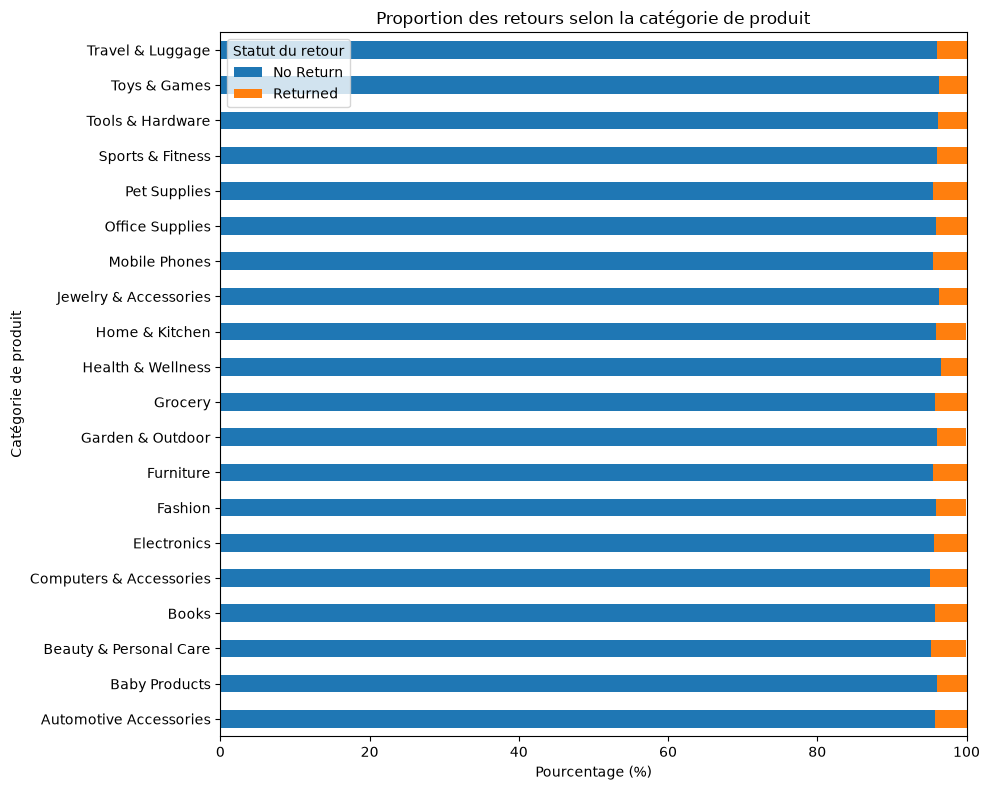

In [42]:
return_by_category.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 8)
)

plt.title("Proportion des retours selon la catégorie de produit")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Catégorie de produit")
plt.legend(title="Statut du retour")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Conclusion

La proportion de commandes retournées reste relativement faible dans
l'ensemble des catégories de produits.

Les proportions de commandes retournées sont assez similaires entre les
différentes catégories, même si de légères variations peuvent être
observées.

Ainsi, dans notre échantillon, aucune différence très importante entre
les catégories ne ressort visuellement concernant le statut de retour.

Cette observation devra toutefois être interprétée avec prudence, car le
graphique permet principalement une comparaison descriptive des
proportions.

## 5 Analyse multivariée

L'analyse multivariée consiste à étudier plusieurs variables simultanément
afin d'identifier des relations plus complexes entre elles.

Dans cette partie, nous utiliserons une heatmap interactive pour explorer
les corrélations entre les principales variables numériques du dataset.

### Matrice de corrélation

La matrice de corrélation permet de mesurer la force et la direction des
relations linéaires entre les variables numériques.

Les coefficients sont compris entre -1 et 1 :
- une valeur proche de 1 indique une relation positive forte ;
- une valeur proche de -1 indique une relation négative forte ;
- une valeur proche de 0 indique une faible relation linéaire.

In [43]:
numeric_data = sample_df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

### Heatmap interactive des corrélations

Une heatmap interactive permet de visualiser simultanément les corrélations
entre les variables numériques.

L'utilisation de Plotly permet également d'explorer les valeurs exactes
des coefficients en passant la souris sur les différentes cellules.

In [44]:
fig = px.imshow(
    correlation_matrix,
    text_auto=".2f",
    aspect="auto",
    title="Matrice de corrélation interactive"
)

fig.update_layout(
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

### Conclusion de l'analyse multivariée

La heatmap interactive permet d'examiner simultanément les relations entre
les différentes variables numériques.

Elle confirme notamment la forte relation positive entre `Net_Sales_USD`
et `Order_Profit_USD`.

Certaines variables financières présentent également des corrélations très
élevées. Ces relations doivent cependant être interprétées avec prudence,
car certaines variables peuvent être directement liées par les calculs
effectués au niveau des transactions.

La heatmap interactive complète ainsi les visualisations précédentes en
permettant une exploration détaillée des coefficients de corrélation.

## 6. Préparation des données pour le dashboard

Les données utilisées pour le dashboard correspondent à l'échantillon
stratifié de 50 000 observations utilisé durant l'analyse exploratoire.

Les données sont exportées dans un fichier CSV afin d'être utilisées
facilement par l'application Streamlit.

In [46]:
sample_df.to_csv(
    "../data/sample_clean.csv",
    index=False
)